In [1]:
from scipy import sparse
from ase.build import molecule
from ase.neighborlist import get_connectivity_matrix
from ase.neighborlist import natural_cutoffs
from ase.neighborlist import NeighborList
import ase
import numpy as np
from ase.io import read
from ase import Atoms
import ase.visualize
from ase.visualize.plot import plot_atoms
from cell2mol.read_write import readinfo
from cell2mol.cell_operations import frac2cart_fromparam, cart2frac
import nglview
from ase.build import molecule
from ase.neighborlist import NeighborList
import matplotlib.pyplot as plt

In [2]:
def view_nglview (ase_object):
    view = nglview.show_ase(ase_object)
    view.add_unitcell()
    return view

In [3]:
folder = "error_2"
name = "BOFFOS"
infopath = f"{folder}/{name}/{name}.info"
input_path = f"{folder}/{name}/{name}.cif"

In [4]:
atoms = read(input_path)
cell_labels = atoms.get_chemical_symbols()
cell_pos = atoms.positions
cell_fracs = atoms.get_scaled_positions()
cell_vector = atoms.cell
# cell_parameters = atoms.cell.cellpar()
space_group = atoms.info['spacegroup']
sym_ops = space_group.get_op()

/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 59 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 0 and 60 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 61 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 2 and 62 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3.10/site-packages/ase/spacegroup/spacegroup.py:433: UserWarning: scaled_positions 3 and 63 are equivalent
  warnings.warn('scaled_positions %d and %d '
/opt/anaconda3/envs/cell2mol/lib/python3

<Axes: >

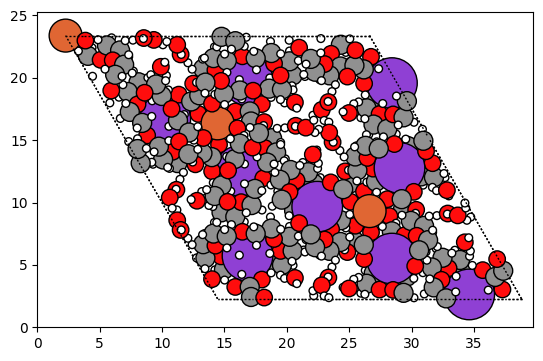

In [5]:
plot_atoms(atoms)

In [6]:
view_nglview(atoms)

NGLWidget()

In [7]:
labels, pos, ref_labels, ref_fracs, cellvec, cellparam = readinfo(infopath)
ref_molecule = Atoms(symbols=ref_labels, scaled_positions=ref_fracs, cell=cell_vector, pbc=True)

<Axes: >

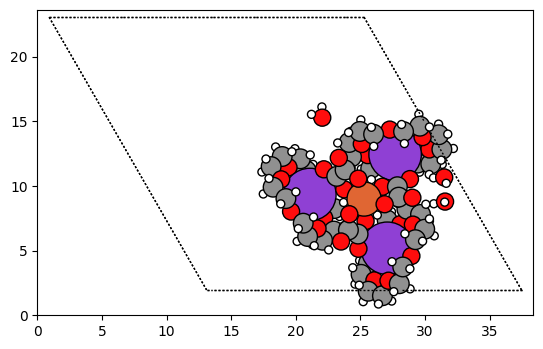

In [8]:
plot_atoms(ref_molecule)

In [9]:
view_nglview(ref_molecule)

NGLWidget()

In [10]:
def apply_symmetry_operations_reference (ref_molecule, cell_vector, sym_ops, normalize=True):
    
    new_structures = []
    ref_labels = ref_molecule.get_chemical_symbols()
    fractional_coords = ref_molecule.get_scaled_positions()
    
    for rot, trans in zip(sym_ops[0], sym_ops[1]):
        transformed_positions = np.dot(fractional_coords, rot.T)
        transformed_positions += np.array(trans)       
        if normalize:
            transformed_positions = np.remainder(transformed_positions, 1)
        new_molecule = Atoms(symbols=ref_labels, scaled_positions=transformed_positions, cell=cell_vector)    
        new_structures.append(new_molecule)
    
    return new_structures

In [11]:
new_structures = apply_symmetry_operations_reference(ref_molecule, cell_vector, sym_ops)

In [12]:
new_structures

[Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False, cell=[[24.369, 0.0, 0.0], [-12.184499999999995, 21.10417306482299, 0.0], [0.0, 0.0, 9.748]]),
 Atoms(symbols='C42H78FeK3O33', pbc=False

In [13]:
view_nglview(new_structures[2])

NGLWidget()

In [14]:
mol = new_structures[2]
# mol = ref_molecule

<Axes: >

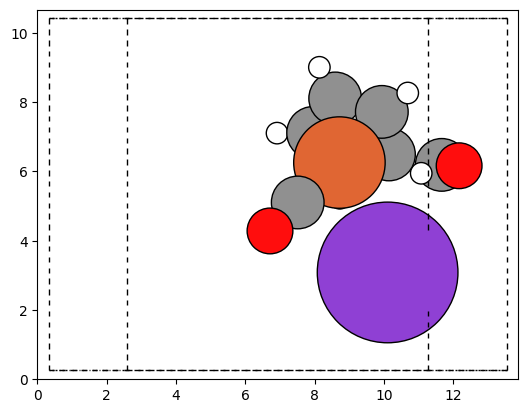

In [15]:
plot_atoms(mol)

In [16]:
cutoffs = natural_cutoffs(mol)

In [17]:
neighbor_list = NeighborList(cutoffs, self_interaction=False, bothways=True)

In [18]:
neighbor_list.update(mol)

True

In [19]:
matrix = neighbor_list.get_connectivity_matrix()

In [20]:
n_components, component_list = sparse.csgraph.connected_components(matrix)

In [21]:
n_components

2

In [22]:
component_list

array([0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [23]:
idx = 12
molIdx = component_list[idx]
print("There are {} molecules in the system".format(n_components))
print("Atom {} is part of molecule {}".format(idx, molIdx))
molIdxs = [i for i in range(len(component_list)) if component_list[i] == molIdx]
print("Atoms are part of molecule {}: {}".format(molIdx, molIdxs))

There are 2 molecules in the system
Atom 12 is part of molecule 0
Atoms are part of molecule 0: [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


In [24]:
view_nglview(mol[0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])

NGLWidget()

0 [0, 1, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
1 [2, 4]


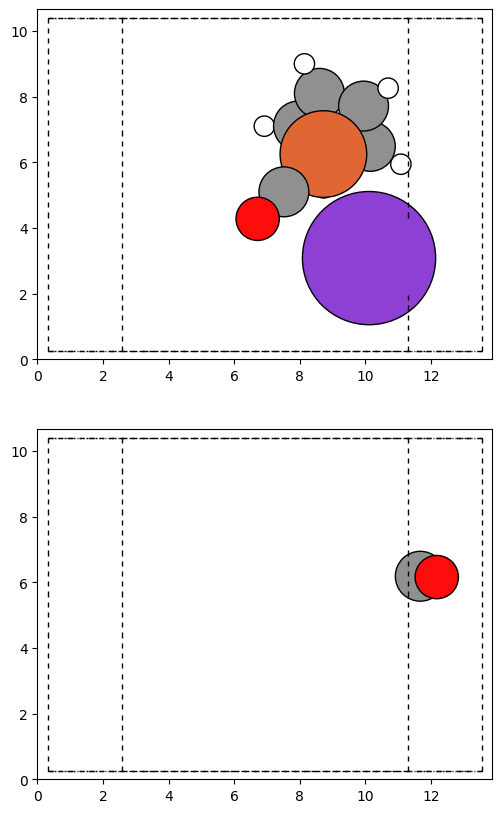

In [25]:
fig, axes = plt.subplots(nrows=n_components, ncols=1, figsize=(20, n_components*5))
for molIdx, ax in zip(range(n_components), axes):
    molIdxs = [i for i in range(len(component_list)) if component_list[i] == molIdx]
    print(molIdx, molIdxs)
    plot_atoms(mol[molIdxs], ax=ax)

In [26]:
from ase.data import covalent_radii, atomic_numbers
from cell2mol.elementdata import ElementData
elementdatabase = ElementData()

for k, v in atomic_numbers.items() :
    if k in elementdatabase.CovalentRadius3.keys():
        if elementdatabase.CovalentRadius3[k] !=  covalent_radii[v] :
            print(k, elementdatabase.CovalentRadius3[k], covalent_radii[v])

C 0.73 0.76


In [14]:
from cell2mol.classes import cell
newcell = cell(name, cell_labels, cell_pos, cellvec, cellparam)
newcell.frac_coord = cell_fracs

In [15]:
debug = 2

In [16]:
newcell.get_reference_molecules(ref_labels, ref_fracs, debug=0)

#########################################
  GETREFS: Generate reference molecules  
#########################################
GETREFS: found 10 reference molecules
GETREFS: ['C6-O12-Fe', 'H24-C12-O6', 'H2-O', 'H2-O', 'H2-O', 'H24-C12-O6', 'H24-C12-O6', 'K', 'K', 'K']
GETREFS: [------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 19
 Formula                      = C6-O12-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
 Number of Ligands            = 3
 Number of Metals             = 1
---------------------------------------------------
, ------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 42
 Formula                      = H24-C12-

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 19
  Formula                      = C6-O12-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Number of Ligands            = 3
  Number of Metals             = 1
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 42
  Formula                      = H24-C12-O6
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
 

In [17]:
newcell

------------- Cell2mol CELL Object ----------------
 Version               = 0.1
 Type                  = cell
 Name (Refcode)        = BOFFOS
 Num Atoms             = 525
 Cell Parameters a:c   = [24.369, 24.369, 9.748]
 Cell Parameters al:ga = [90.0, 90.0, 120.0]
---------------------------------------------------
 # of Ref Molecules:   = 10
 With Formulae:                                  
    0: C6-O12-Fe 
    1: H24-C12-O6 
    2: H2-O 
    3: H2-O 
    4: H2-O 
    5: H24-C12-O6 
    6: H24-C12-O6 
    7: K 
    8: K 
    9: K 

In [18]:
import itertools

In [ ]:
from new_reconstruction import *
all_found = []
all_molecules = []
debug = 2
reconstructed_molecules = []
for new in new_structures:
    found_indices, found_rows = find_row_indices(cell_pos, new.positions)
    print(len(found_indices), len(found_rows))
    
    updated = [i for i in found_indices if i not in all_found]

    new_fracs = new.get_scaled_positions()
    new_labels =  new.get_chemical_symbols()
    indices_in_ref = [ find_row_index_from_matrix(new_fracs, cell_fracs[u]) for u in updated ]
    print(f"{indices_in_ref=}")
    all_found.extend(updated)
    print(len(all_found))
    
    print(len(all_found) == len(cell_pos))# If Ture, stop

    # #### make blocks and get fragments ####
    fragments = get_fragments (newcell, updated, indices_in_ref, debug=0)
    print([frag.formula for frag in fragments], [frag.ref_indices for frag in fragments])
    
    molecules, found_list, remaining_fragments, not_found_list = classify_fragments(fragments, newcell, debug=debug)
    
    all_molecules.extend(molecules)
    # print(f"{found_list=}\n{molecules=}")
    print(f"{not_found_list=}")
    print("remaining_fragments:", [rem.formula for rem in remaining_fragments])
    print("remaining_fragments:", [rem.subtype for rem in remaining_fragments])
    grouped_rem_frags, indices_from_rem_frags, indices_of_target_ref = grouping_remaining_fragments(remaining_fragments, not_found_list, newcell, debug=debug)
    print(f"{grouped_rem_frags=} {indices_from_rem_frags=}")
    all_found_molecules = []
    for indices, target_ref in zip(indices_from_rem_frags, indices_of_target_ref):
        subset_remaining_fragments = [ remaining_fragments[idx] for idx in indices]
        list_of_found_molecules, final_remaining = find_molecule_from_subset_rem_frags(subset_remaining_fragments, target_ref, cell_vector, debug=0)
        reconstructed_molecules.extend(list_of_found_molecules)
        
        if len(final_remaining) > 0 :
            Warning = True
        elif len(final_remaining) == 0 :
            Warning = False      
            
    if len(all_found) == len(cell_pos):
        break
all_molecules.extend(reconstructed_molecules)

157 157
indices_in_ref=[0, 59, 60, 1, 2, 61, 62, 3, 63, 64, 4, 65, 66, 5, 67, 68, 6, 69, 70, 7, 71, 72, 8, 73, 74, 9, 75, 76, 10, 77, 78, 11, 80, 79, 12, 13, 14, 15, 81, 82, 16, 83, 84, 17, 85, 86, 18, 87, 88, 19, 90, 89, 20, 92, 91, 21, 93, 94, 22, 95, 96, 23, 97, 98, 24, 99, 100, 25, 101, 102, 26, 103, 104, 27, 105, 106, 28, 107, 108, 29, 109, 110, 30, 111, 112, 31, 114, 113, 32, 116, 115, 33, 117, 118, 34, 119, 120, 35, 121, 122, 36, 123, 124, 37, 125, 126, 38, 127, 128, 39, 129, 130, 40, 131, 132, 41, 133, 134, 42, 135, 136, 43, 138, 137, 44, 140, 139, 45, 142, 141, 46, 144, 143, 47, 146, 145, 48, 148, 147, 49, 150, 149, 50, 152, 151, 51, 153, 154, 52, 155, 156, 53, 54, 55, 56, 57, 58]
157
False
['C3-O6-Fe', 'C-O2', 'C-O2', 'C-O2', 'H3-C2', 'H-C-O', 'H-O', 'H2-O', 'H3-C2', 'H2-O', 'H14-C8-O5', 'H2-C', 'H2-C', 'H2-C', 'H-C-O', 'H19-C11-O6', 'H14-C8-O5', 'H', 'H', 'K', 'K', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'H', 'K'] [[1, 8, 73, 74, 9, 75, 76, 51, 153, 154], [10, 11, 52], 

In [35]:
all_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.classify_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version    

In [34]:
reconstructed_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H5-C7-O2-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H5-C7-O2-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.reconstruct
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Ver

In [43]:
all_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version              

In [44]:
final_remaining

[]

In [45]:
Warning

Warning

In [34]:
all_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version              

In [35]:
grouped_rem_frags

[[0, 6, 7, 8, 9, 10, 11, 12, 14, 15, 3, 5, 2, 4, 13]]

In [36]:
indices_from_rem_frags

[[0, 1, 2, 3]]

In [37]:
indices_of_target_ref

[[0, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]]

In [38]:
remaining_fragments

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = fragment
  Number of Atoms              = 10
  Formula                      = H4-C5-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = fragment
  Number of Atoms              = 2
  Formula                      = C-O
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version    

In [39]:
all_found_molecules = []
for indices, target_ref in zip(indices_from_rem_frags, indices_of_target_ref):
    subset_remaining_fragments = [ remaining_fragments[idx] for idx in indices]
    list_of_found_molecules, final_remaining = find_molecule_from_subset_rem_frags(subset_remaining_fragments, target_ref, cell_vector, debug=0)
    all_found_molecules.extend(list_of_found_molecules)
    
    if len(final_remaining) > 0 :
        Warning = True
    elif len(final_remaining) == 0 :
        Warning == False

final_remaining ['H4-C5-Fe', 'C-O', 'C-O', 'H'] ['fragment', 'fragment', 'fragment', 'fragment']
Fragments TO BE MERGED ['H4-C5-Fe', 'C-O'] ['fragment', 'fragment']
Rest fragments ['C-O', 'H'] ['fragment', 'fragment']
------------- Cell2mol MOLECULE Object --------------
 Version                      = 0.1
 Type                         = specie
 Sub-Type                     = molecule
 Number of Atoms              = 12
 Formula                      = H4-C6-O-Fe
 Covalent Radii Factor        = 1.3
 Metal Radii Factor           = 1.0
 Has Adjacency Matrix         = YES
---------------------------------------------------

MERGED H4-C6-O-Fe [0, 6, 7, 8, 9, 10, 11, 12, 14, 15, 3, 5]
small_set={0, 3, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15}
len(found_molecule)=0
len(bigger_fragment)=1
len(not_merged)=0
Fragments TO BE MERGED ['H4-C5-Fe', 'C-O'] ['fragment', 'fragment']
Rest fragments ['C-O', 'H'] ['fragment', 'fragment']
------------- Cell2mol MOLECULE Object --------------
 Version               

In [40]:
all_found_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 15
  Formula                      = H5-C7-O2-Fe
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
 ---------------------------------------------------]

In [41]:
all_molecules

[------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version                      = 0.1
  Type                         = specie
  Sub-Type                     = molecule
  Number of Atoms              = 1
  Formula                      = K
  Covalent Radii Factor        = 1.3
  Metal Radii Factor           = 1.0
  Has Adjacency Matrix         = YES
  Origin                       = cell.get_fragments
 ---------------------------------------------------,
 ------------- Cell2mol MOLECULE Object --------------
  Version              